### Imports Sys


In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split, cross_val_score

from src.data.loader        import load_all
from src.data.cleaner       import clean_medals, clean_countries
from src.features.builder   import build_features, get_feature_cols
from src.evaluation.metrics import regression_metrics, clustering_metrics
from src.evaluation.plotter import (plot_medal_trends, plot_feature_importance,
                                     plot_actual_vs_pred, plot_cluster_heatmap,
                                     plot_elbow)

### Load data and features


In [2]:
medals_raw, countries_raw = load_all(config_path='../config/config.yaml')
medals    = clean_medals(medals_raw)
countries = clean_countries(countries_raw)
features  = build_features(medals, countries).dropna()
feat_cols = get_feature_cols(features)
X = features[feat_cols].values
y = features['TotalMedals'].values
_, X_test, _, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

✅ Medals loaded: (36935, 12) | Countries: (201, 5)
   Summer records : 31,165
   Winter records : 5,770
   Project root used: C:\Users\ACER\OneDrive\Desktop\Bull\Olympics-ML-Analysis


### Load saved models


In [3]:
rf  = joblib.load('../models/trained/regression_rf.pkl')
clf = joblib.load('../models/trained/classification_rf.pkl')
km  = joblib.load('../models/trained/clustering_kmeans.pkl')
le  = joblib.load('../models/trained/label_encoder.pkl')
print('All models loaded.')

All models loaded.


### Regression evaluation


In [4]:
mets = regression_metrics(y_test, rf.predict(X_test))
print('--- Regression metrics ---')
print('RMSE:', mets['rmse'])
print('MAE :', mets['mae'])
print('R2  :', mets['r2'])

--- Regression metrics ---
RMSE: 6.0173
MAE : 3.0156
R2  : 0.9543


### Cross validation scores


In [5]:
cv = cross_val_score(rf, X, y, scoring='neg_root_mean_squared_error', cv=5)
print('CV RMSE scores:', [-round(s, 3) for s in cv])
print('CV mean RMSE  :', round(-cv.mean(), 3))

CV RMSE scores: [7.016, 9.207, 3.517, 5.881, 26.98]
CV mean RMSE  : 10.52


### Actual vs predicted plot


In [6]:
plot_actual_vs_pred(y_test, rf.predict(X_test))

### Feature importance plot


In [7]:
plot_feature_importance(rf, feat_cols, 'regression_feature_importance')

### Medal trends plot


In [8]:
plot_medal_trends(features, top_n=10)

### Residuals analysis


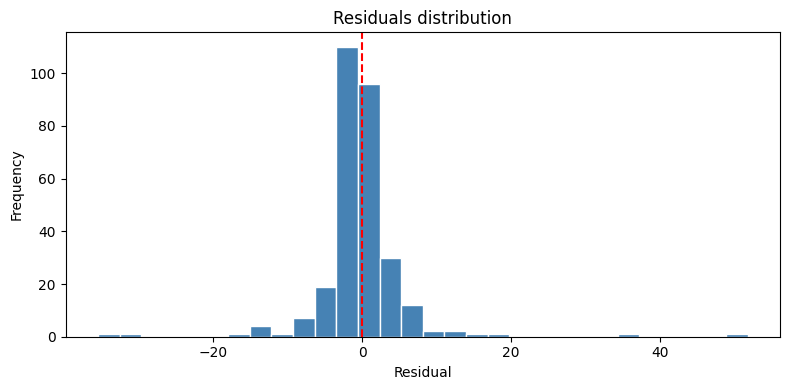

In [9]:
residuals = y_test - rf.predict(X_test)
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(residuals, bins=30, color='steelblue', edgecolor='white')
ax.axvline(0, color='red', linestyle='--')
ax.set_title('Residuals distribution')
ax.set_xlabel('Residual')
ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

### Clustering evaluation


In [10]:
country_agg = features.groupby('Country')[feat_cols].mean().dropna().reset_index()
Xk          = country_agg[feat_cols].values
labels      = km.named_steps['kmeans'].labels_
from sklearn.preprocessing import StandardScaler
Xk_scaled   = StandardScaler().fit_transform(Xk)
clust_mets  = clustering_metrics(Xk_scaled, labels)
print('Silhouette score:', clust_mets['silhouette'])

Silhouette score: 0.7453


### Cluster heatmap


In [11]:
country_agg['Cluster'] = labels
plot_cluster_heatmap(country_agg, feat_cols)

### Countries per cluster


In [12]:
print('Countries per cluster:')
print(country_agg.groupby('Cluster')['Country'].apply(list))

Countries per cluster:
Cluster
0    [AUS, AUT, Afghanistan, Algeria, Argentina, Ar...
1       [China, Germany, India, Russia, United States]
Name: Country, dtype: object


### Top countries per cluster


In [13]:
country_agg = (features
               .groupby('Country')
               .agg({col: 'mean' for col in feat_cols + ['TotalMedals']})
               .dropna()
               .reset_index())

country_agg['Cluster'] = km.named_steps['kmeans'].labels_


for cluster_id in sorted(country_agg['Cluster'].unique()):
    grp = country_agg[country_agg['Cluster'] == cluster_id].copy()
    top = grp.nlargest(5, 'TotalMedals')[['Country', 'TotalMedals']]
    print(f'\nCluster {cluster_id} — top 5 countries:')
    print(top.to_string(index=False))


Cluster 0 — top 5 countries:
       Country  TotalMedals
United Kingdom    63.703704
           EUN    60.000000
        France    53.692308
         Italy    51.840000
     Australia    49.541667

Cluster 1 — top 5 countries:
      Country  TotalMedals
United States   176.346154
       Russia   153.600000
        China   100.875000
      Germany    87.000000
        India    10.823529


### Predict for a specific country


In [14]:
country = 'United States'
year    = 2028
row = features[(features['Country'] == country)]
if not row.empty:
    X_pred = row[feat_cols].mean().values.reshape(1, -1)
    pred   = rf.predict(X_pred)[0]
    print(f'Predicted medals for {country} in {year}: {pred:.1f}')

Predicted medals for United States in 2028: 155.4


### Save evaluation summary


In [15]:
import json, os
os.makedirs('../results/metrics', exist_ok=True)
summary = {
    'regression': mets,
    'clustering': clust_mets,
}
with open('../results/metrics/evaluation_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)
print('Evaluation summary saved to results/metrics/evaluation_summary.json')

Evaluation summary saved to results/metrics/evaluation_summary.json
